In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.6/172.6 kB 4.5 MB/s eta 0:00:00


⚖️ Applying SMOTE to balance the training data...
Before SMOTE: Legitimate = 34993, Phishing = 20965
After SMOTE:  Legitimate = 34993, Phishing = 34993

🔍 Running GridSearchCV for KNN...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Best Parameters Found:
{'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

✅ Evaluating final KNN model...


🔹 Evaluating Category: Hard
              precision    recall  f1-score   support

           0     0.9854    0.9700    0.9777      7178
           1     0.7598    0.8685    0.8105       783

    accuracy                         0.9601      7961
   macro avg     0.8726    0.9193    0.8941      7961
weighted avg     0.9632    0.9601    0.9612      7961

✅ Accuracy for Hard: 0.9601

🔹 Evaluating Category: Medium
              precision    recall  f1-score   support

           0     0.9623    0.9203    0.9408      5707
           1     0.8168    0.9078    0.8599      2235

    accuracy                         0.

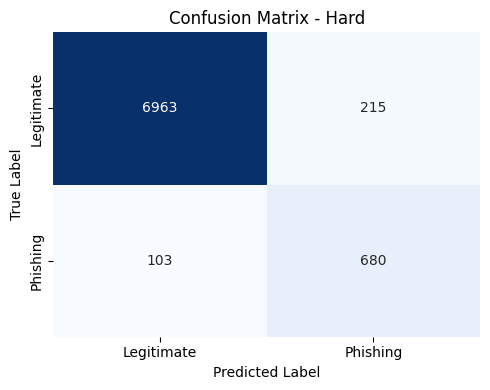

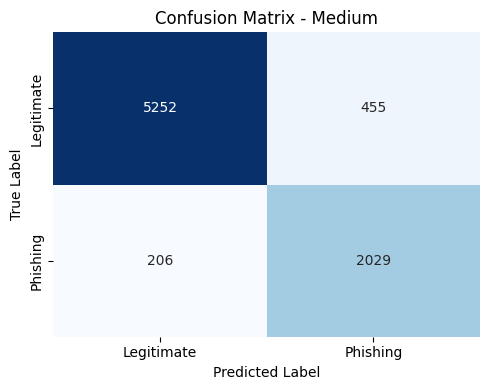

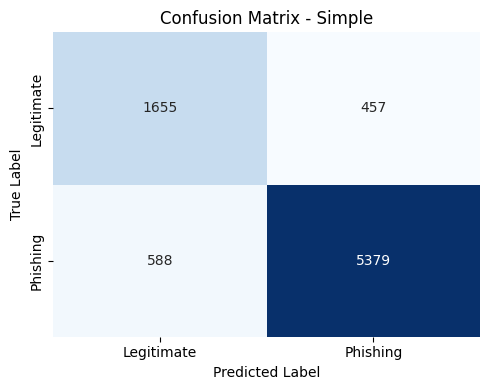

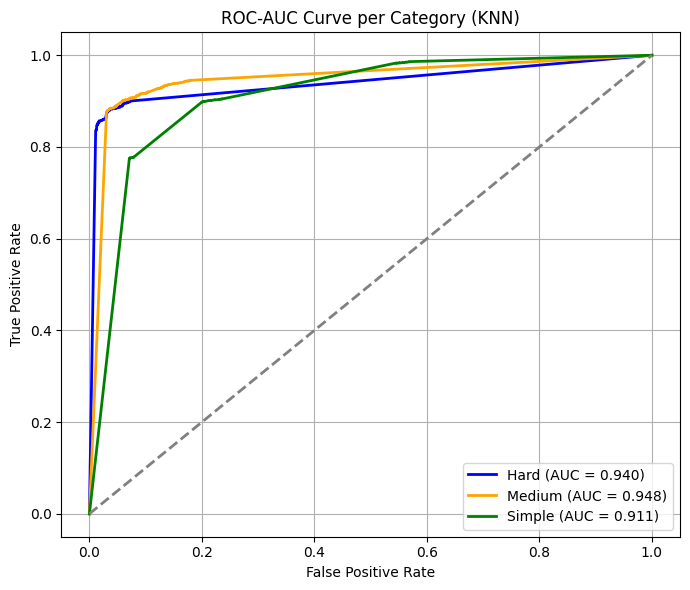

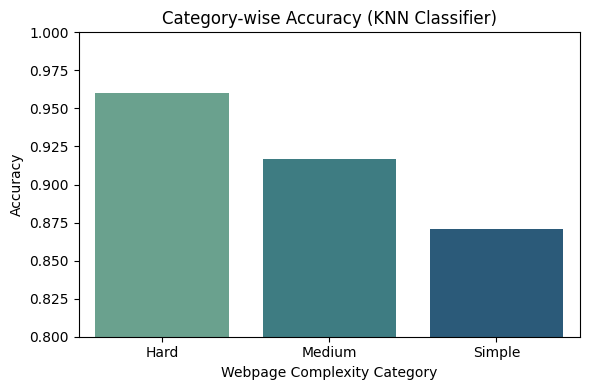


🌍 Overall Accuracy (Global Test Set): 0.9156


In [ ]:

# K-Nearest Neighbors (KNN) with SMOTE + GridSearch + Category-wise Evaluation + Graphs


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")


#  Load Dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")

# Define features and labels
X = df.drop(columns=["label", "category", "complexity_score"])
y = df["label"]


#  Global Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#  Apply SMOTE for Balancing the Training Data

print(" Applying SMOTE to balance the training data...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: Legitimate = {sum(y_train==0)}, Phishing = {sum(y_train==1)}")
print(f"After SMOTE:  Legitimate = {sum(y_train_res==0)}, Phishing = {sum(y_train_res==1)}")


#  Define KNN Model and Hyperparameter Grid

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': list(range(3, 21, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'euclidean'],
    'p': [1, 2]
}


#  GridSearchCV for Optimal Parameters

print("\n Running GridSearchCV for KNN...")
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train_res, y_train_res)

print("\n Best Parameters Found:")
print(grid_search.best_params_)

best_knn = grid_search.best_estimator_


#  Evaluate Model on Each Complexity Category

print("\n Evaluating final KNN model...\n")

X_test_eval = X_test.copy()
X_test_eval["label_true"] = y_test
X_test_eval["label_pred"] = best_knn.predict(X_test)
X_test_eval["category"] = df.loc[X_test.index, "category"].values
X_test_eval["pred_prob"] = best_knn.predict_proba(X_test)[:, 1]

results = {}
conf_matrices = {}

for cat in X_test_eval["category"].unique():
    print(f"\n🔹 Evaluating Category: {cat}")
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_pred = subset["label_pred"]

    acc = accuracy_score(y_true, y_pred)
    print(classification_report(y_true, y_pred, digits=4))
    print(f" Accuracy for {cat}: {acc:.4f}")

    results[cat] = acc
    conf_matrices[cat] = confusion_matrix(y_true, y_pred)

#  Confusion Matrix Visualization

for cat, cm in conf_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Legitimate", "Phishing"],
                yticklabels=["Legitimate", "Phishing"])
    plt.title(f"Confusion Matrix - {cat}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


#  ROC Curve and AUC per Category

plt.figure(figsize=(7, 6))
colors = cycle(["blue", "orange", "green", "red", "purple"])

for cat, color in zip(X_test_eval["category"].unique(), colors):
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_score = best_knn.predict_proba(subset.drop(columns=["label_true","label_pred","category","pred_prob"]))[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cat} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve per Category (KNN)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#  Category-wise Accuracy Bar Chart

plt.figure(figsize=(6, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="crest")
plt.title("Category-wise Accuracy (KNN Classifier)")
plt.xlabel("Webpage Complexity Category")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


# Overall Evaluation

overall_acc = accuracy_score(y_test, best_knn.predict(X_test))
print(f"\n Overall Accuracy (Global Test Set): {overall_acc:.4f}")


⚖️ Applying SMOTE to balance the training data...
Before SMOTE: Legitimate = 34993, Phishing = 20965
After SMOTE:  Legitimate = 34993, Phishing = 34993

🔍 Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits

✅ Best Parameters Found:
{'bootstrap': False, 'max_depth': 120, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 1500}

✅ Trained unified RandomForest model on all data.


🔹 Evaluating Category: Hard
              precision    recall  f1-score   support

           0     0.9828    0.9960    0.9893      7178
           1     0.9578    0.8404    0.8952       783

    accuracy                         0.9807      7961
   macro avg     0.9703    0.9182    0.9423      7961
weighted avg     0.9804    0.9807    0.9801      7961

✅ Accuracy for Hard: 0.9807

🔹 Evaluating Category: Medium
              precision    recall  f1-score   support

           0     0.9617    0.9683    0.9650      5707
           1     0.9176    0.9016 

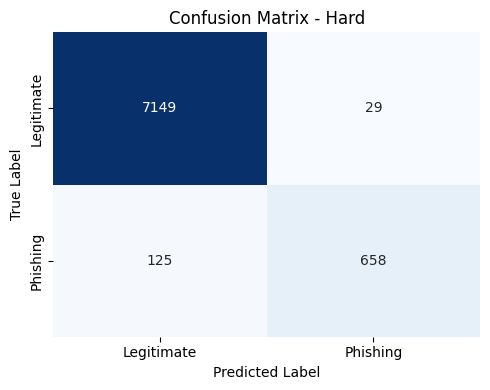

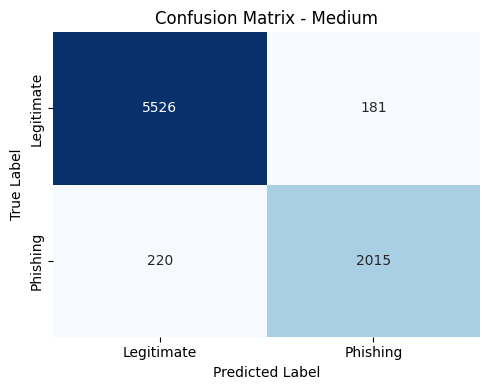

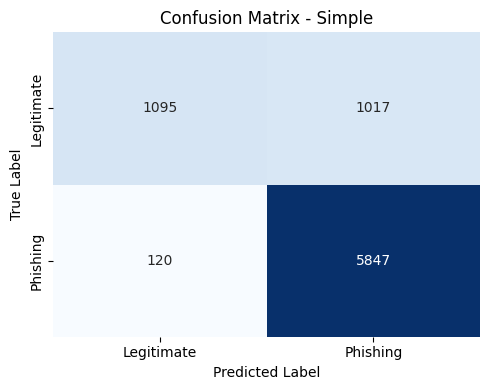

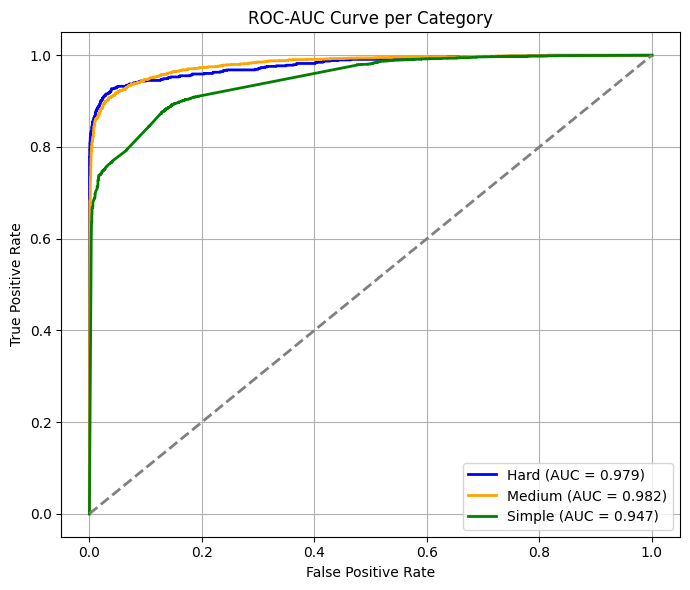

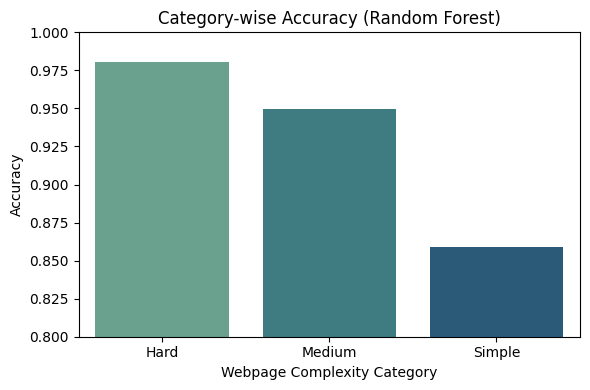


🌍 Overall Accuracy (Global Test Set): 0.9294


In [ ]:

#  Random Forest with SMOTE + GridSearch + Category-wise Evaluation + Graphs


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")


#  Load Dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")

# Define features and label
X = df.drop(columns=["label", "category", "complexity_score"])
y = df["label"]


#  Global Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#  Apply SMOTE for Balancing the Training Data

print(" Applying SMOTE to balance the training data...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: Legitimate = {sum(y_train==0)}, Phishing = {sum(y_train==1)}")
print(f"After SMOTE:  Legitimate = {sum(y_train_resampled==0)}, Phishing = {sum(y_train_resampled==1)}")


#  Define Hyperparameter Grid for Random Forest

param_grid_rf = {
    'n_estimators': [1500],
    'max_features': ['log2'],
    'max_depth': [120],
    'min_samples_split': [5],
    'bootstrap': [False]
}


#  GridSearchCV for Optimal Parameters

rf_model = RandomForestClassifier(random_state=3, class_weight='balanced')
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

print("\n Running GridSearchCV for RandomForest...")
grid_rf.fit(X_train_resampled, y_train_resampled)

print("\n Best Parameters Found:")
print(grid_rf.best_params_)

rf_best = grid_rf.best_estimator_


#  Evaluate Model on Each Complexity Category

print("\n Trained unified RandomForest model on all data.\n")

X_test_eval = X_test.copy()
X_test_eval["label_true"] = y_test
X_test_eval["label_pred"] = rf_best.predict(X_test)
X_test_eval["category"] = df.loc[X_test.index, "category"].values
X_test_eval["pred_prob"] = rf_best.predict_proba(X_test)[:, 1]

results = {}
conf_matrices = {}

for cat in X_test_eval["category"].unique():
    print(f"\n🔹 Evaluating Category: {cat}")
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_pred = subset["label_pred"]

    acc = accuracy_score(y_true, y_pred)
    print(classification_report(y_true, y_pred, digits=4))
    print(f" Accuracy for {cat}: {acc:.4f}")

    results[cat] = acc
    conf_matrices[cat] = confusion_matrix(y_true, y_pred)


#  Confusion Matrix Visualization

for cat, cm in conf_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Legitimate", "Phishing"],
                yticklabels=["Legitimate", "Phishing"])
    plt.title(f"Confusion Matrix - {cat}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


#  ROC Curve and AUC per Category

plt.figure(figsize=(7, 6))
colors = cycle(["blue", "orange", "green", "red", "purple"])

for cat, color in zip(X_test_eval["category"].unique(), colors):
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_score = rf_best.predict_proba(subset.drop(columns=["label_true","label_pred","category","pred_prob"]))[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cat} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve per Category")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


#  Category-wise Accuracy Bar Chart

plt.figure(figsize=(6, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="crest")
plt.title("Category-wise Accuracy (Random Forest)")
plt.xlabel("Webpage Complexity Category")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


# Overall Evaluation

overall_acc = accuracy_score(y_test, rf_best.predict(X_test))
print(f"\n Overall Accuracy (Global Test Set): {overall_acc:.4f}")



🔹 CATEGORY: Hard
Best params for RandomForestClassifier: {'bootstrap': False, 'max_depth': 40, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 1000}
Best params for XGBClassifier: {'colsample_bytree': 0.75, 'learning_rate': 0.07, 'max_depth': 20, 'n_estimators': 1000, 'reg_alpha': 0.5, 'subsample': 1.0}
Best params for LogisticRegression: {'C': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best params for KNeighborsClassifier: {'metric': 'manhattan', 'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
Best params for MLPClassifier: {'activation': 'logistic', 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'random_state': 42, 'solver': 'adam'}


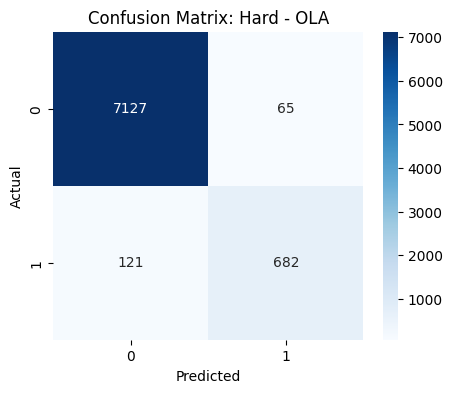

ROC-AUC not available for OLA in category Hard

 Results - OLA
              precision    recall  f1-score   support

           0     0.9833    0.9910    0.9871      7192
           1     0.9130    0.8493    0.8800       803

    accuracy                         0.9767      7995
   macro avg     0.9481    0.9201    0.9336      7995
weighted avg     0.9762    0.9767    0.9764      7995



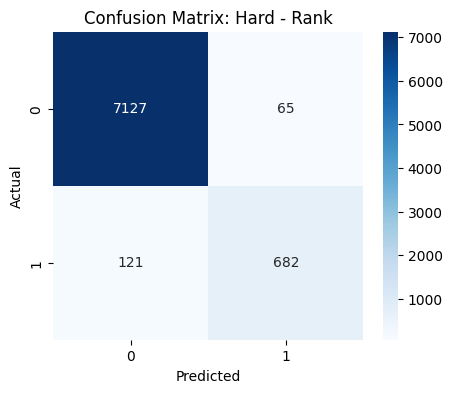

ROC-AUC not available for Rank in category Hard

 Results - Rank
              precision    recall  f1-score   support

           0     0.9833    0.9910    0.9871      7192
           1     0.9130    0.8493    0.8800       803

    accuracy                         0.9767      7995
   macro avg     0.9481    0.9201    0.9336      7995
weighted avg     0.9762    0.9767    0.9764      7995



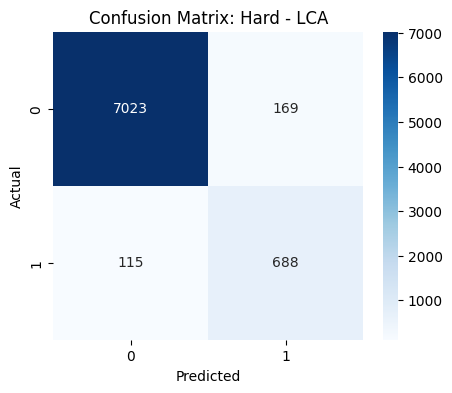

ROC-AUC not available for LCA in category Hard

 Results - LCA
              precision    recall  f1-score   support

           0     0.9839    0.9765    0.9802      7192
           1     0.8028    0.8568    0.8289       803

    accuracy                         0.9645      7995
   macro avg     0.8933    0.9166    0.9045      7995
weighted avg     0.9657    0.9645    0.9650      7995



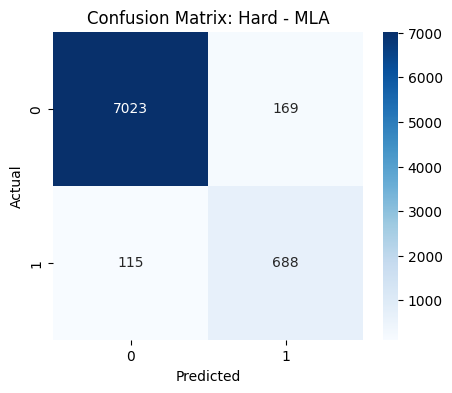

ROC-AUC not available for MLA in category Hard

 Results - MLA
              precision    recall  f1-score   support

           0     0.9839    0.9765    0.9802      7192
           1     0.8028    0.8568    0.8289       803

    accuracy                         0.9645      7995
   macro avg     0.8933    0.9166    0.9045      7995
weighted avg     0.9657    0.9645    0.9650      7995



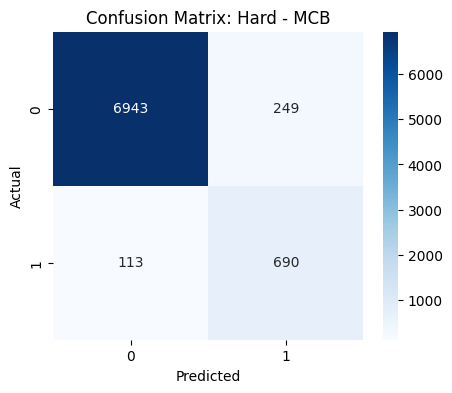

ROC-AUC not available for MCB in category Hard

 Results - MCB
              precision    recall  f1-score   support

           0     0.9840    0.9654    0.9746      7192
           1     0.7348    0.8593    0.7922       803

    accuracy                         0.9547      7995
   macro avg     0.8594    0.9123    0.8834      7995
weighted avg     0.9590    0.9547    0.9563      7995


🔹 CATEGORY: Medium
Best params for RandomForestClassifier: {'bootstrap': False, 'max_depth': 40, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 1000}
Best params for XGBClassifier: {'colsample_bytree': 0.75, 'learning_rate': 0.07, 'max_depth': 20, 'n_estimators': 1000, 'reg_alpha': 0.5, 'subsample': 1.0}
Best params for LogisticRegression: {'C': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best params for KNeighborsClassifier: {'metric': 'manhattan', 'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
Best params for MLPClassifier: {'activation': 'logistic

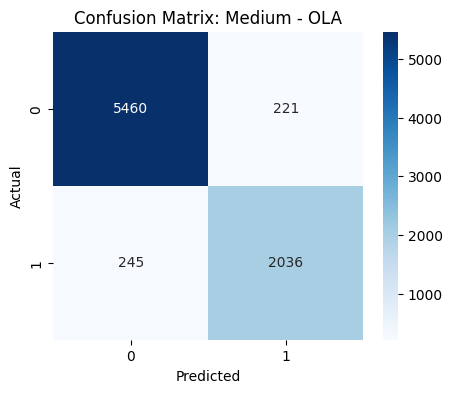

ROC-AUC not available for OLA in category Medium

 Results - OLA
              precision    recall  f1-score   support

           0     0.9571    0.9611    0.9591      5681
           1     0.9021    0.8926    0.8973      2281

    accuracy                         0.9415      7962
   macro avg     0.9296    0.9268    0.9282      7962
weighted avg     0.9413    0.9415    0.9414      7962



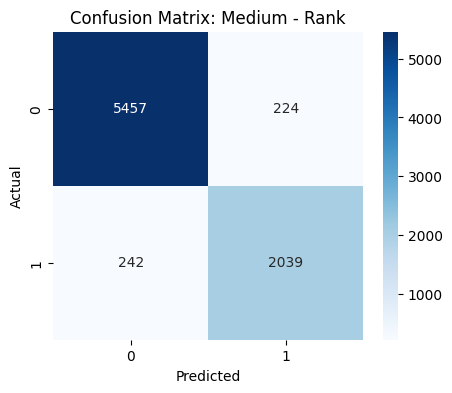

ROC-AUC not available for Rank in category Medium

 Results - Rank
              precision    recall  f1-score   support

           0     0.9575    0.9606    0.9591      5681
           1     0.9010    0.8939    0.8974      2281

    accuracy                         0.9415      7962
   macro avg     0.9293    0.9272    0.9282      7962
weighted avg     0.9413    0.9415    0.9414      7962



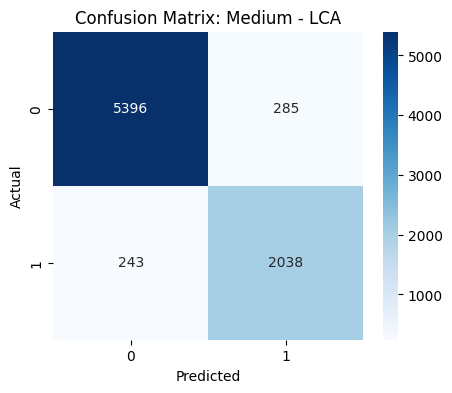

ROC-AUC not available for LCA in category Medium

 Results - LCA
              precision    recall  f1-score   support

           0     0.9569    0.9498    0.9534      5681
           1     0.8773    0.8935    0.8853      2281

    accuracy                         0.9337      7962
   macro avg     0.9171    0.9217    0.9193      7962
weighted avg     0.9341    0.9337    0.9339      7962



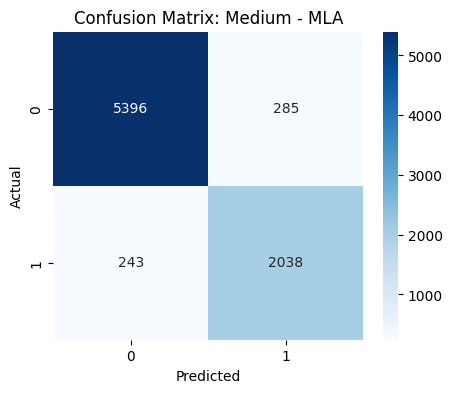

ROC-AUC not available for MLA in category Medium

 Results - MLA
              precision    recall  f1-score   support

           0     0.9569    0.9498    0.9534      5681
           1     0.8773    0.8935    0.8853      2281

    accuracy                         0.9337      7962
   macro avg     0.9171    0.9217    0.9193      7962
weighted avg     0.9341    0.9337    0.9339      7962



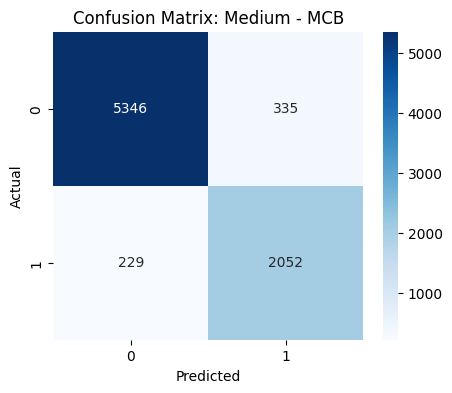

ROC-AUC not available for MCB in category Medium

 Results - MCB
              precision    recall  f1-score   support

           0     0.9589    0.9410    0.9499      5681
           1     0.8597    0.8996    0.8792      2281

    accuracy                         0.9292      7962
   macro avg     0.9093    0.9203    0.9145      7962
weighted avg     0.9305    0.9292    0.9296      7962


🔹 CATEGORY: Simple
Best params for RandomForestClassifier: {'bootstrap': False, 'max_depth': 40, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 1000}
Best params for XGBClassifier: {'colsample_bytree': 0.75, 'learning_rate': 0.07, 'max_depth': 20, 'n_estimators': 1000, 'reg_alpha': 0.5, 'subsample': 1.0}
Best params for LogisticRegression: {'C': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best params for KNeighborsClassifier: {'metric': 'manhattan', 'n_neighbors': 18, 'p': 1, 'weights': 'distance'}
Best params for MLPClassifier: {'activation': 'logis

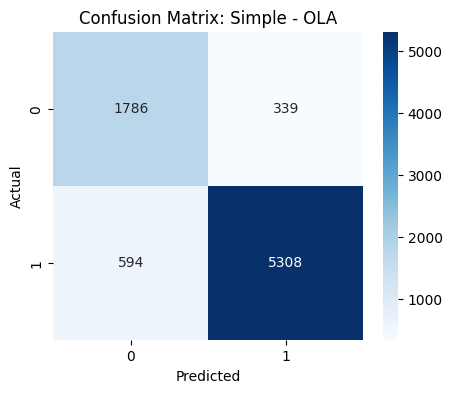

ROC-AUC not available for OLA in category Simple

 Results - OLA
              precision    recall  f1-score   support

           0     0.7504    0.8405    0.7929      2125
           1     0.9400    0.8994    0.9192      5902

    accuracy                         0.8838      8027
   macro avg     0.8452    0.8699    0.8561      8027
weighted avg     0.8898    0.8838    0.8858      8027



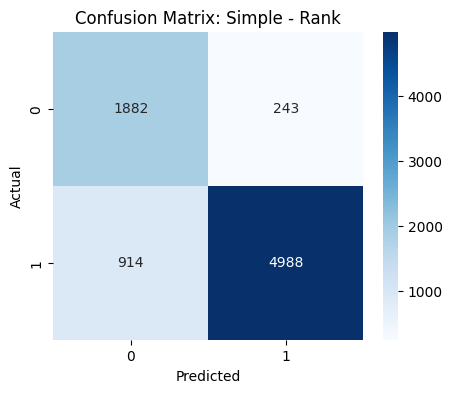

ROC-AUC not available for Rank in category Simple

 Results - Rank
              precision    recall  f1-score   support

           0     0.6731    0.8856    0.7649      2125
           1     0.9535    0.8451    0.8961      5902

    accuracy                         0.8559      8027
   macro avg     0.8133    0.8654    0.8305      8027
weighted avg     0.8793    0.8559    0.8613      8027



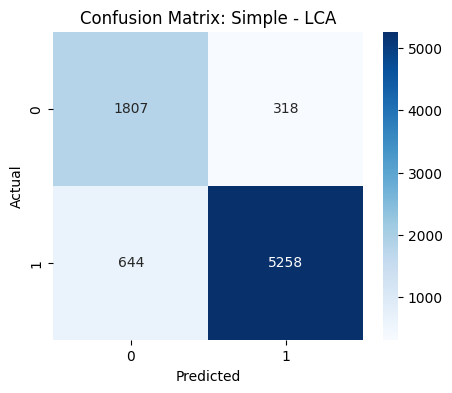

ROC-AUC not available for LCA in category Simple

 Results - LCA
              precision    recall  f1-score   support

           0     0.7373    0.8504    0.7898      2125
           1     0.9430    0.8909    0.9162      5902

    accuracy                         0.8802      8027
   macro avg     0.8401    0.8706    0.8530      8027
weighted avg     0.8885    0.8802    0.8827      8027



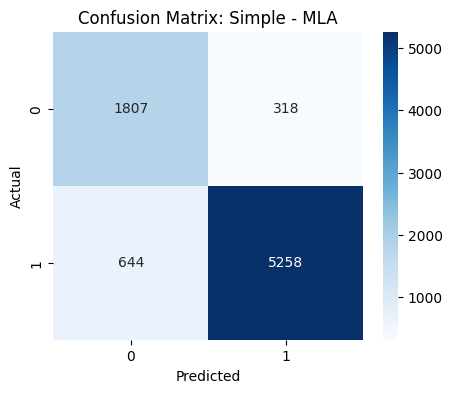

ROC-AUC not available for MLA in category Simple

 Results - MLA
              precision    recall  f1-score   support

           0     0.7373    0.8504    0.7898      2125
           1     0.9430    0.8909    0.9162      5902

    accuracy                         0.8802      8027
   macro avg     0.8401    0.8706    0.8530      8027
weighted avg     0.8885    0.8802    0.8827      8027



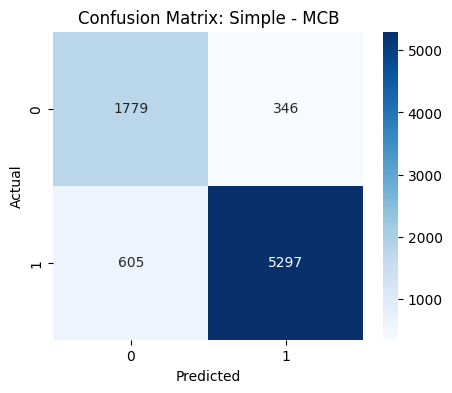

ROC-AUC not available for MCB in category Simple

 Results - MCB
              precision    recall  f1-score   support

           0     0.7462    0.8372    0.7891      2125
           1     0.9387    0.8975    0.9176      5902

    accuracy                         0.8815      8027
   macro avg     0.8425    0.8673    0.8534      8027
weighted avg     0.8877    0.8815    0.8836      8027



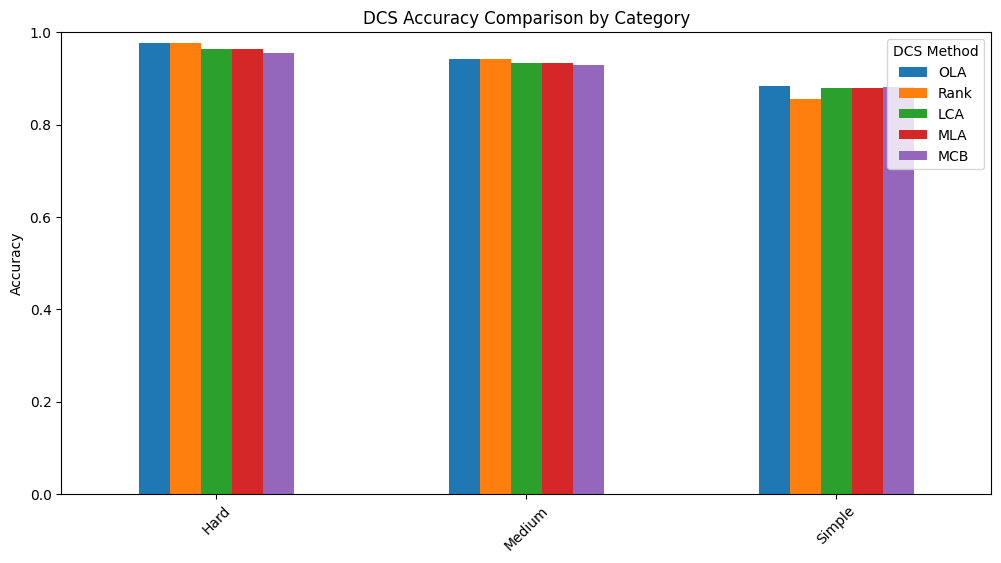


Summary of ROC-AUC by Category:
         OLA  Rank   LCA   MLA   MCB
Hard    None  None  None  None  None
Medium  None  None  None  None  None
Simple  None  None  None  None  None

Summary of Accuracy by Category:
           OLA    Rank     LCA     MLA     MCB
Hard    0.9767  0.9767  0.9645  0.9645  0.9547
Medium  0.9415  0.9415  0.9337  0.9337  0.9292
Simple  0.8838  0.8559  0.8802  0.8802  0.8815


In [ ]:

#  DCS (OLA, Rank, LCA, MLA, MCB) for Each Category
# with Confusion Matrix, Accuracy Bar Chart, ROC Curves & AUC


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

# DESlib imports
from deslib.dcs import OLA, LCA, MLA, Rank, MCB

import warnings
warnings.filterwarnings("ignore")


#  Load categorized dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")


#  Parameter Grids

param_grid_rf = {'n_estimators': [1000], 'max_features': ['log2'], 'max_depth': [40], 'min_samples_split': [5], 'bootstrap': [False]}
param_grid_xgb = {'n_estimators': [1000], 'max_depth': [20], 'learning_rate': [0.07], 'subsample': [1.0], 'colsample_bytree': [0.75], 'reg_alpha': [0.5]}
param_grid_lr = {'C': [1], 'l1_ratio': [0.5], 'max_iter': [1000], 'solver': ['liblinear'], 'penalty': ['l1']}
param_grid_knn = {'n_neighbors': list(range(1, 21)), 'weights': ['distance'], 'metric': ['manhattan'], 'p': [1]}
param_grid_nn = {'activation': ['logistic'], 'hidden_layer_sizes': [(100, 50)], 'learning_rate': ['constant'], 'learning_rate_init': [0.01], 'random_state': [42], 'solver': ['adam']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#  Model tuning function

def tune_model(model, param_grid, X, y):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)
    print(f"Best params for {type(model).__name__}: {grid.best_params_}")
    return grid.best_estimator_


#  Category-wise evaluation (OLA, Rank, LCA, MLA, MCB)

results = {}
confusion_matrices = {}
roc_auc_scores = {}

for cat in df["category"].unique():
    print(f"\n🔹 CATEGORY: {cat}")
    subset = df[df["category"] == cat]

    X = subset.drop(columns=["label", "category", "complexity_score"])
    y = subset["label"]
    classes = sorted(y.unique())
    y_bin = label_binarize(y, classes=classes)  # for multi-class ROC

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Apply SMOTE for balance
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Tune base models
    rf = RandomForestClassifier(random_state=42)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    lr = LogisticRegression(max_iter=1000, solver='liblinear')
    knn = KNeighborsClassifier()
    nn = MLPClassifier(max_iter=500, random_state=42)

    best_rf = tune_model(rf, param_grid_rf, X_train_resampled, y_train_resampled)
    best_xgb = tune_model(xgb, param_grid_xgb, X_train_resampled, y_train_resampled)
    best_lr = tune_model(lr, param_grid_lr, X_train_resampled, y_train_resampled)
    best_knn = tune_model(knn, param_grid_knn, X_train_resampled, y_train_resampled)
    best_nn = tune_model(nn, param_grid_nn, X_train_resampled, y_train_resampled)

    # Pool of classifiers
    pool_classifiers = [best_rf, best_xgb, best_lr, best_knn, best_nn]

    # Dictionary to store metrics for this category
    cat_metrics = {}
    cat_roc_auc = {}

    # List of DCS methods
    dcs_methods = {"OLA": OLA, "Rank": Rank, "LCA": LCA, "MLA": MLA, "MCB": MCB}

    for name, DCS in dcs_methods.items():
        dcs_model = DCS(pool_classifiers=pool_classifiers)
        dcs_model.fit(X_train_resampled, y_train_resampled)
        y_pred = dcs_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        cat_metrics[name] = acc

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices[f"{cat}_{name}"] = cm

        # Plot confusion matrix
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix: {cat} - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # ROC-AUC (One-vs-Rest)
        try:
            y_test_bin = label_binarize(y_test, classes=classes)
            if hasattr(dcs_model, "predict_proba"):
                y_score = dcs_model.predict_proba(X_test)
            else:
                # fallback to decision_function
                y_score = dcs_model.decision_function(X_test)
            auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
            cat_roc_auc[name] = auc

            # Plot ROC curve
            RocCurveDisplay.from_predictions(
                y_test_bin, y_score, name=f"{name}", color=None, alpha=0.8
            )
            plt.title(f"ROC Curve - {cat} - {name}")
            plt.show()
        except:
            print(f"ROC-AUC not available for {name} in category {cat}")
            cat_roc_auc[name] = None

        # Classification report
        print(f"\n Results - {name}")
        print(classification_report(y_test, y_pred, digits=4))

    results[cat] = cat_metrics
    roc_auc_scores[cat] = cat_roc_auc


#  Summary

# Accuracy comparison bar chart
summary_df = pd.DataFrame(results).T
summary_df.plot(kind='bar', figsize=(12, 6))
plt.title("DCS Accuracy Comparison by Category")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="DCS Method")
plt.show()

# ROC-AUC summary table
roc_auc_df = pd.DataFrame(roc_auc_scores).T
print("\nSummary of ROC-AUC by Category:")
print(roc_auc_df.round(4))

# Display summary table
print("\nSummary of Accuracy by Category:")
print(summary_df.round(4))




🔹 CATEGORY: Hard
✅ Best params for RandomForestClassifier: {'bootstrap': False, 'max_depth': 40, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 1000}
✅ Best params for XGBClassifier: {'colsample_bytree': 0.75, 'learning_rate': 0.07, 'max_depth': 20, 'n_estimators': 1000, 'reg_alpha': 0.5, 'subsample': 1.0}
✅ Best params for LogisticRegression: {'C': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
✅ Best params for KNeighborsClassifier: {'metric': 'manhattan', 'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
✅ Best params for MLPClassifier: {'activation': 'logistic', 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'random_state': 42, 'solver': 'adam'}

🔸 KNORAE Results for Hard: Accuracy = 0.9741
              precision    recall  f1-score   support

           0     0.9841    0.9872    0.9856      7192
           1     0.8821    0.8568    0.8692       803

    accuracy                         0.97

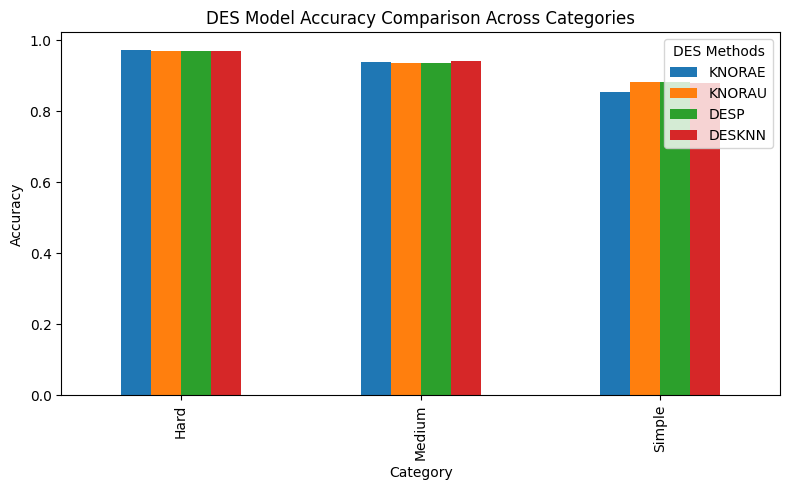


📊 Summary of DES Accuracy by Category:
          KNORAE    KNORAU      DESP    DESKNN
Hard    0.974109  0.970482  0.971482  0.971607
Medium  0.940342  0.935946  0.937704  0.942979
Simple  0.855239  0.882397  0.884141  0.879158


In [ ]:

#  Dynamic Ensemble Selection (DES) + Visualization


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from deslib.des import KNORAE, KNORAU, DESP, DESKNN
import numpy as np
import warnings
warnings.filterwarnings("ignore")


#  Load Dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")


#  Parameter Grids (same as before)

param_grid_rf = {'n_estimators':[1000],'max_features':['log2'],'max_depth':[40],'min_samples_split':[5],'bootstrap':[False]}
param_grid_xgb = {'n_estimators':[1000],'max_depth':[20],'learning_rate':[0.07],'subsample':[1.0],'colsample_bytree':[0.75],'reg_alpha':[0.5]}
param_grid_lr  = {'C':[1],'l1_ratio':[0.5],'max_iter':[1000],'solver':['liblinear'],'penalty':['l1']}
param_grid_knn = {'n_neighbors':list(range(1,21)),'weights':['distance'],'metric':['manhattan'],'p':[1]}
param_grid_nn  = {'activation':['logistic'],'hidden_layer_sizes':[(100,50)],'learning_rate':['constant'],
                  'learning_rate_init':[0.01],'random_state':[42],'solver':['adam']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_model(model, param_grid, X, y):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)
    print(f" Best params for {type(model).__name__}: {grid.best_params_}")
    return grid.best_estimator_


#  Helper Function: Plot Confusion Matrix

def plot_conf_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Legitimate (0)", "Phishing (1)"],
                yticklabels=["Legitimate (0)", "Phishing (1)"])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()


#  Helper Function: ROC Curve

def plot_roc(y_true, y_pred_prob, title, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()


#  Category-wise DES Evaluation

results = {}

for cat in df["category"].unique():
    print(f"\n🔹 CATEGORY: {cat}")
    subset = df[df["category"] == cat]
    X = subset.drop(columns=["label","category","complexity_score"])
    y = subset["label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                        random_state=42, stratify=y)
    smote = SMOTE(random_state=42)
    x_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    rf  = tune_model(RandomForestClassifier(random_state=42), param_grid_rf, x_train_res, y_train_res)
    xgb = tune_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
                     param_grid_xgb, x_train_res, y_train_res)
    lr  = tune_model(LogisticRegression(max_iter=1000, solver='liblinear'),
                     param_grid_lr, x_train_res, y_train_res)
    knn = tune_model(KNeighborsClassifier(), param_grid_knn, x_train_res, y_train_res)
    nn  = tune_model(MLPClassifier(max_iter=500, random_state=42), param_grid_nn, x_train_res, y_train_res)

    pool = [rf, xgb, lr, knn, nn]
    des_models = {
        "KNORAE": KNORAE(pool),
        "KNORAU": KNORAU(pool),
        "DESP": DESP(pool),
        "DESKNN": DESKNN(pool)
    }

    category_results = {}
    for name, model in des_models.items():
        model.fit(x_train_res, y_train_res)
        y_pred = model.predict(X_test)
        y_pred_prob = np.vstack([m.predict_proba(X_test)[:,1] for m in pool]).mean(axis=0)
        acc = accuracy_score(y_test, y_pred)
        category_results[name] = acc
        print(f"\n🔸 {name} Results for {cat}: Accuracy = {acc:.4f}")
        print(classification_report(y_test, y_pred, digits=4))

        # Plot confusion matrix & ROC curve
        plot_conf_matrix(y_test, y_pred, f"{name} Confusion Matrix ({cat})",
                         f"{cat}_{name}_confusion_matrix.png")
        plot_roc(y_test, np.column_stack((1-y_pred_prob, y_pred_prob)),
                 f"{name} ROC Curve ({cat})", f"{cat}_{name}_roc.png")

    results[cat] = category_results


#  Summary Bar Graph

summary_df = pd.DataFrame(results).T
summary_df.plot(kind='bar', figsize=(8,5))
plt.title("DES Model Accuracy Comparison Across Categories")
plt.ylabel("Accuracy")
plt.xlabel("Category")
plt.legend(title="DES Methods")
plt.tight_layout()
plt.savefig("DES_summary_accuracy.png", dpi=300)
plt.show()

print("\n Summary of DES Accuracy by Category:")
print(summary_df)


Before SMOTE: Legitimate = 34993, Phishing = 20965
After SMOTE:  Legitimate = 34993, Phishing = 34993

🔹 Evaluating Category: Hard
              precision    recall  f1-score   support

           0     0.9851    0.9946    0.9898      7178
           1     0.9454    0.8621    0.9018       783

    accuracy                         0.9815      7961
   macro avg     0.9652    0.9283    0.9458      7961
weighted avg     0.9812    0.9815    0.9812      7961

✅ Accuracy for Hard: 0.9815

🔹 Evaluating Category: Medium
              precision    recall  f1-score   support

           0     0.9623    0.9618    0.9621      5707
           1     0.9026    0.9038    0.9032      2235

    accuracy                         0.9455      7942
   macro avg     0.9324    0.9328    0.9326      7942
weighted avg     0.9455    0.9455    0.9455      7942

✅ Accuracy for Medium: 0.9455

🔹 Evaluating Category: Simple
              precision    recall  f1-score   support

           0     0.9018    0.5090    0.6

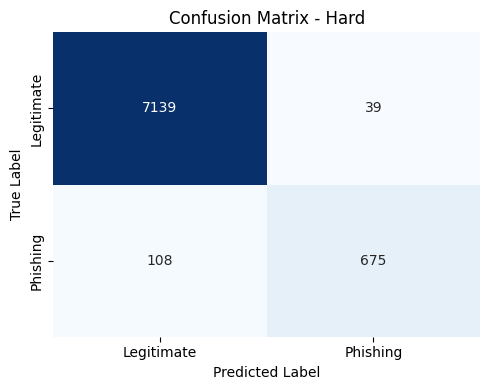

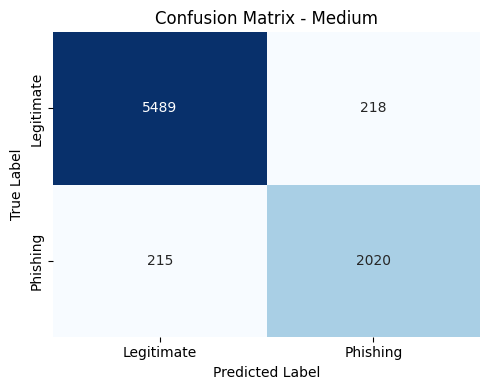

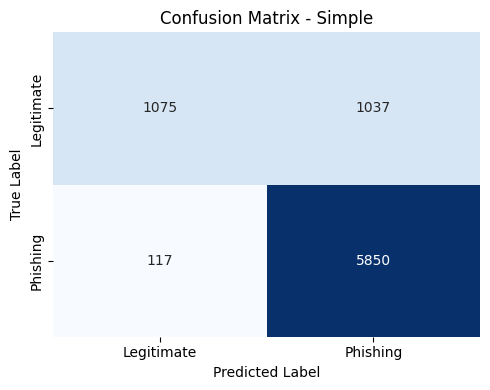

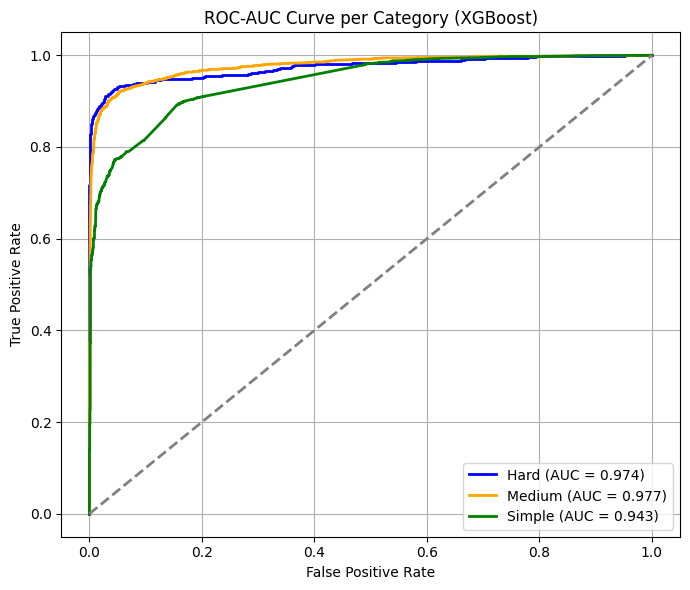

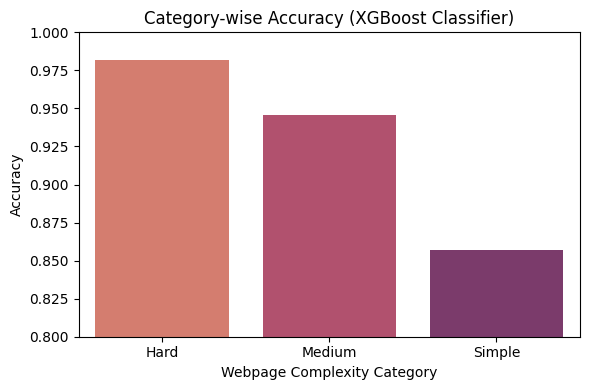


🌍 Overall Accuracy (Global Test Set): 0.9277


In [ ]:

#  Optimized XGBoost with SMOTE + Category-wise Evaluation


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, auc
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")


#  Load Dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")

# Features and label
X = df.drop(columns=["label", "category", "complexity_score"])
y = df["label"]


#  Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#  Apply SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: Legitimate = {sum(y_train==0)}, Phishing = {sum(y_train==1)}")
print(f"After SMOTE:  Legitimate = {sum(y_train_res==0)}, Phishing = {sum(y_train_res==1)}")


#  Train XGBoost with Best Parameters

xgb_best = XGBClassifier(
    n_estimators=1000,
    max_depth=20,
    learning_rate=0.07,
    colsample_bytree=0.75,
    gamma=0,
    reg_alpha=0.5,
    reg_lambda=1,
    subsample=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_best.fit(X_train_res, y_train_res)


#  Category-wise Evaluation

X_test_eval = X_test.copy()
X_test_eval["label_true"] = y_test
X_test_eval["label_pred"] = xgb_best.predict(X_test)
X_test_eval["category"] = df.loc[X_test.index, "category"].values
X_test_eval["pred_prob"] = xgb_best.predict_proba(X_test)[:, 1]

results = {}
conf_matrices = {}

for cat in X_test_eval["category"].unique():
    print(f"\n🔹 Evaluating Category: {cat}")
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_pred = subset["label_pred"]

    acc = accuracy_score(y_true, y_pred)
    print(classification_report(y_true, y_pred, digits=4))
    print(f" Accuracy for {cat}: {acc:.4f}")

    results[cat] = acc
    conf_matrices[cat] = confusion_matrix(y_true, y_pred)


#  Confusion Matrix Visualization

for cat, cm in conf_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Legitimate", "Phishing"],
                yticklabels=["Legitimate", "Phishing"])
    plt.title(f"Confusion Matrix - {cat}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


#  ROC Curve and AUC per Category

plt.figure(figsize=(7, 6))
colors = cycle(["blue", "orange", "green", "red", "purple"])

for cat, color in zip(X_test_eval["category"].unique(), colors):
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_score = xgb_best.predict_proba(subset.drop(columns=["label_true","label_pred","category","pred_prob"]))[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cat} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve per Category (XGBoost)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


#  Category-wise Accuracy Bar Chart

plt.figure(figsize=(6, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="flare")
plt.title("Category-wise Accuracy (XGBoost Classifier)")
plt.xlabel("Webpage Complexity Category")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


#  Overall Accuracy

overall_acc = accuracy_score(y_test, xgb_best.predict(X_test))
print(f"\n Overall Accuracy (Global Test Set): {overall_acc:.4f}")


Before SMOTE: Legitimate = 34993, Phishing = 20965
After SMOTE:  Legitimate = 34993, Phishing = 34993

🔹 Category: Hard | Accuracy: 0.9040
              precision    recall  f1-score   support

           0     0.9171    0.9823    0.9486      7178
           1     0.5348    0.1865    0.2765       783

    accuracy                         0.9040      7961
   macro avg     0.7260    0.5844    0.6126      7961
weighted avg     0.8795    0.9040    0.8825      7961


🔹 Category: Medium | Accuracy: 0.6904
              precision    recall  f1-score   support

           0     0.9196    0.6236    0.7432      5707
           1     0.4725    0.8609    0.6101      2235

    accuracy                         0.6904      7942
   macro avg     0.6961    0.7422    0.6767      7942
weighted avg     0.7938    0.6904    0.7058      7942


🔹 Category: Simple | Accuracy: 0.7397
              precision    recall  f1-score   support

           0     0.5789    0.0156    0.0304      2112
           1     0.7

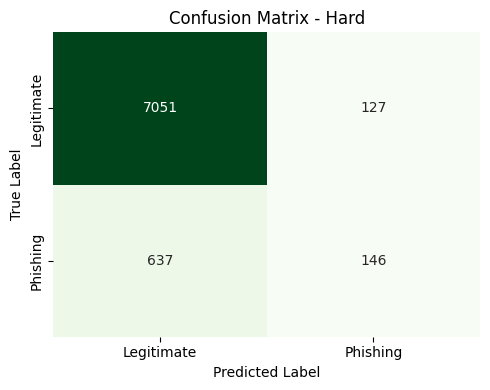

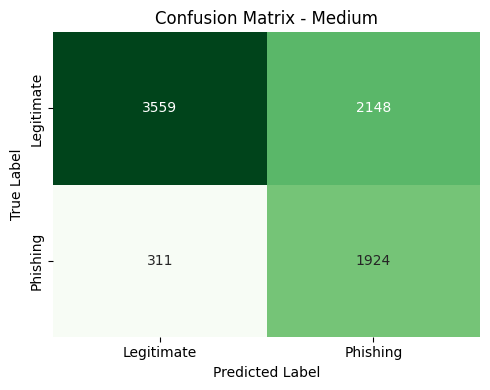

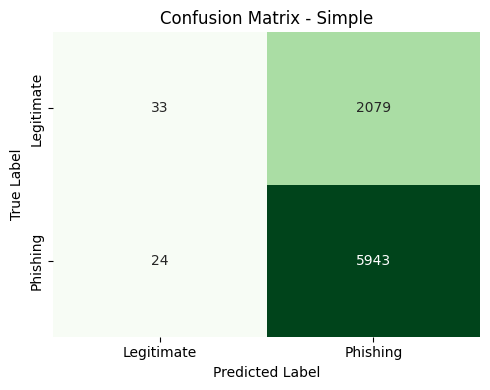

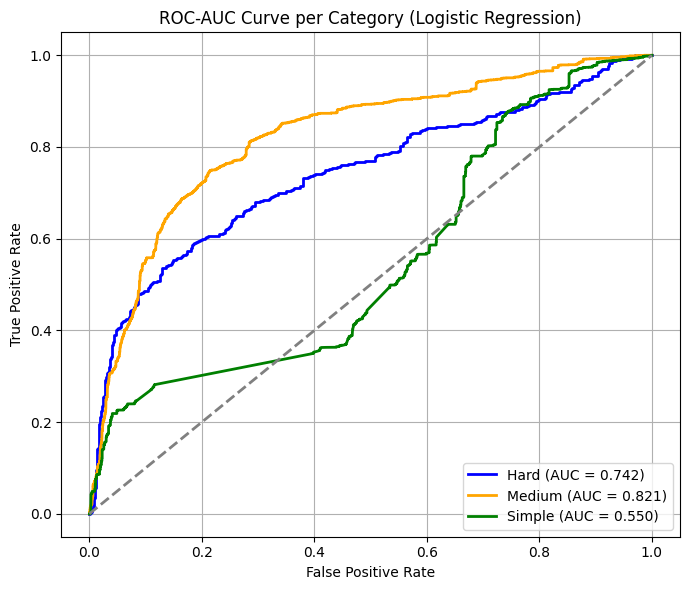

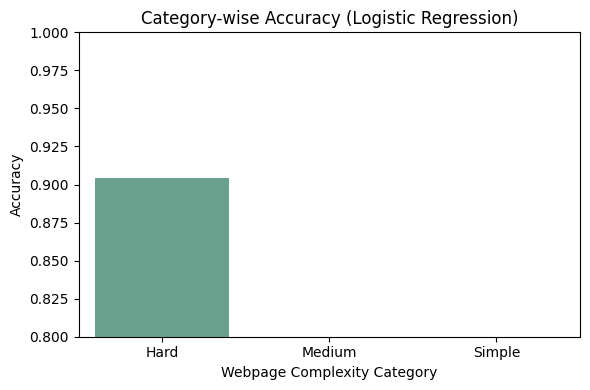


🌍 Overall Accuracy (Global Test Set): 0.7779


In [ ]:

#  Optimized Logistic Regression with SMOTE + Category-wise Evaluation


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")

#  Load Dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")

X = df.drop(columns=["label", "category", "complexity_score"])
y = df["label"]


#  Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#  Scale Features and Apply SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: Legitimate = {sum(y_train==0)}, Phishing = {sum(y_train==1)}")
print(f"After SMOTE:  Legitimate = {sum(y_train_res==0)}, Phishing = {sum(y_train_res==1)}")


#  Train Logistic Regression with fixed parameters

lr_best = LogisticRegression(
    penalty='l2',
    C=1,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_best.fit(X_train_res, y_train_res)


#  Category-wise Evaluation

X_test_eval = X_test.copy()
X_test_eval["label_true"] = y_test
X_test_eval["label_pred"] = lr_best.predict(X_test_scaled)
X_test_eval["category"] = df.loc[X_test.index, "category"].values
X_test_eval["pred_prob"] = lr_best.predict_proba(X_test_scaled)[:, 1]

results = {}
conf_matrices = {}

for cat in X_test_eval["category"].unique():
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_pred = subset["label_pred"]

    acc = accuracy_score(y_true, y_pred)
    print(f"\n🔹 Category: {cat} | Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

    results[cat] = acc
    conf_matrices[cat] = confusion_matrix(y_true, y_pred)


#  Confusion Matrix Visualization

for cat, cm in conf_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=["Legitimate", "Phishing"],
                yticklabels=["Legitimate", "Phishing"])
    plt.title(f"Confusion Matrix - {cat}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


#  ROC Curve and AUC per Category

plt.figure(figsize=(7, 6))
colors = cycle(["blue", "orange", "green", "red", "purple"])

for cat, color in zip(X_test_eval["category"].unique(), colors):
    subset = X_test_eval[X_test_eval["category"] == cat]
    y_true = subset["label_true"]
    y_score = subset["pred_prob"]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cat} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve per Category (Logistic Regression)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


#  Category-wise Accuracy Bar Chart

plt.figure(figsize=(6, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="crest")
plt.title("Category-wise Accuracy (Logistic Regression)")
plt.xlabel("Webpage Complexity Category")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()


#  Overall Accuracy

overall_acc = accuracy_score(y_test, lr_best.predict(X_test_scaled))
print(f"\n Overall Accuracy (Global Test Set): {overall_acc:.4f}")


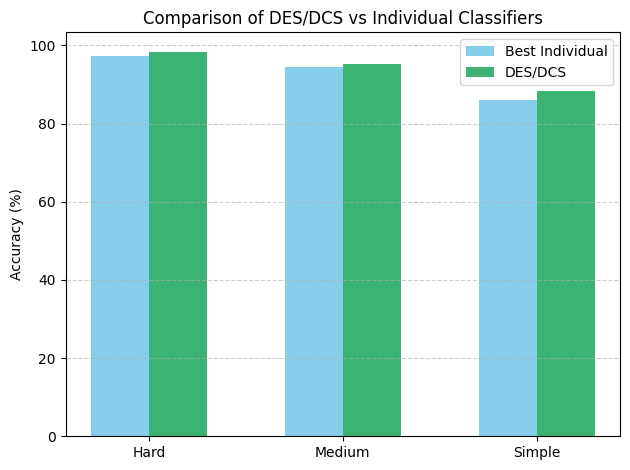

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["Hard", "Medium", "Simple"]
individual = [97.15, 94.55, 86.07]
des = [98.41, 95.30, 88.41]

x = np.arange(len(categories))
plt.bar(x-0.15, individual, width=0.3, label='Best Individual', color='skyblue')
plt.bar(x+0.15, des, width=0.3, label='DES/DCS', color='mediumseagreen')
plt.ylabel("Accuracy (%)")
plt.title("Comparison of DES/DCS vs Individual Classifiers")
plt.xticks(x, categories)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("comparison_des_individual.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# ============================
#  LOAD DATASET
# ============================
df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")

# ============================
#  PARAMETER GRID FOR MLP
# ============================
param_grid_nn = {
    "hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "learning_rate_init": [0.001, 0.0005]
}


#  MODEL TUNING FUNCTION

def tune_model(model, param_grid, X_train, y_train):
    grid = GridSearchCV(model, param_grid, scoring="accuracy", cv=3, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    print("Best Params:", grid.best_params_)
    return grid.best_estimator_


#  FUNCTION TO TRAIN + EVALUATE ON ONE CATEGORY (WITH SMOTE)

def evaluate_category(category_name, data):

    print(f"     Evaluating Category: {category_name}")


    # Split features and labels
    X = data.drop(columns=["label", "category"])
    y = data["label"]

    # Train–Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )


    #  APPLY SMOTE

    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


    #  SCALE FEATURES

    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_test = scaler.transform(X_test)

    #  TRAIN MLP WITH GRID SEARCH

    mlp = tune_model(
        MLPClassifier(max_iter=500, random_state=42),
        param_grid_nn,
        X_train_res,
        y_train_res
    )

    #  PREDICTIONS

    y_pred = mlp.predict(X_test)


    #  METRICS

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # PRINT RESULTS
    print(f"\nResults ({category_name}):")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    return {
        "Category": category_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

#  SPLIT DATA INTO CATEGORIES

simple_df = df[df['category'] == "Simple"]
medium_df = df[df['category'] == "Medium"]
hard_df = df[df['category'] == "Hard"]


#  RUN EVALUATION

results = []
results.append(evaluate_category("Simple", simple_df))
results.append(evaluate_category("Medium", medium_df))
results.append(evaluate_category("Hard", hard_df))


#  DISPLAY ALL RESULTS

results_df = pd.DataFrame(results)
print("\n FINAL RESULTS TABLE ")
print(results_df)



     Evaluating Category: Simple
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'activation': 'tanh', 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'solver': 'adam'}

Results (Simple):
Accuracy   : 0.8708
Precision  : 0.9316
Recall     : 0.8896
F1 Score   : 0.9101

     Evaluating Category: Medium
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'activation': 'tanh', 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'solver': 'adam'}

Results (Medium):
Accuracy   : 0.8977
Precision  : 0.7901
Recall     : 0.8753
F1 Score   : 0.8305

     Evaluating Category: Hard
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'activation': 'tanh', 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'solver': 'adam'}

Results (Hard):
Accuracy   : 0.9427
Precision  : 0.6744
Recall     : 0.8296
F1 Score   : 0.7440

========= FINAL RESULTS TABLE =========
  Category  Accuracy  Precision    R

In [ ]:

# DCS (OLA, Rank, LCA, MLA, MCB) for Each Category
# with Confusion Matrix, Accuracy Bar Chart, ROC Curves & AUC


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

# DESlib imports
from deslib.dcs import OLA, LCA, MLA, Rank, MCB

import warnings
warnings.filterwarnings("ignore")


#  Load categorized dataset

df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")


#  Parameter Grids

param_grid_rf = {'n_estimators': [1000], 'max_features': ['log2'], 'max_depth': [40], 'min_samples_split': [5], 'bootstrap': [False]}
param_grid_xgb = {'n_estimators': [1000], 'max_depth': [20], 'learning_rate': [0.07], 'subsample': [1.0], 'colsample_bytree': [0.75], 'reg_alpha': [0.5]}
param_grid_lr = {'C': [1], 'l1_ratio': [0.5], 'max_iter': [1000], 'solver': ['liblinear'], 'penalty': ['l1']}
param_grid_knn = {'n_neighbors': list(range(1, 21)), 'weights': ['distance'], 'metric': ['manhattan'], 'p': [1]}
param_grid_nn = {'activation': ['logistic'], 'hidden_layer_sizes': [(100, 50)], 'learning_rate': ['constant'], 'learning_rate_init': [0.01], 'random_state': [42], 'solver': ['adam']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#  Model tuning function

def tune_model(model, param_grid, X, y):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)
    print(f"Best params for {type(model).__name__}: {grid.best_params_}")
    return grid.best_estimator_


#  Category-wise evaluation (OLA, Rank, LCA, MLA, MCB)

results = {}
confusion_matrices = {}
roc_auc_scores = {}

for cat in df["category"].unique():
    print(f"\n🔹 CATEGORY: {cat}")
    subset = df[df["category"] == cat]

    X = subset.drop(columns=["label", "category", "complexity_score"])
    y = subset["label"]
    classes = sorted(y.unique())
    y_bin = label_binarize(y, classes=classes)  # for multi-class ROC

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Apply SMOTE for balance
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Tune base models
    rf = RandomForestClassifier(random_state=42)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    lr = LogisticRegression(max_iter=1000, solver='liblinear')
    knn = KNeighborsClassifier()
    nn = MLPClassifier(max_iter=500, random_state=42)

    best_rf = tune_model(rf, param_grid_rf, X_train_resampled, y_train_resampled)
    best_xgb = tune_model(xgb, param_grid_xgb, X_train_resampled, y_train_resampled)
    best_lr = tune_model(lr, param_grid_lr, X_train_resampled, y_train_resampled)
    best_knn = tune_model(knn, param_grid_knn, X_train_resampled, y_train_resampled)
    best_nn = tune_model(nn, param_grid_nn, X_train_resampled, y_train_resampled)

    # Pool of classifiers
    pool_classifiers = [best_rf, best_xgb, best_lr, best_knn, best_nn]

    # Dictionary to store metrics for this category
    cat_metrics = {}
    cat_roc_auc = {}

    # List of DCS methods
    dcs_methods = {"OLA": OLA, "Rank": Rank, "LCA": LCA, "MLA": MLA, "MCB": MCB}

    for name, DCS in dcs_methods.items():
        dcs_model = DCS(pool_classifiers=pool_classifiers)
        dcs_model.fit(X_train_resampled, y_train_resampled)
        y_pred = dcs_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        cat_metrics[name] = acc

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices[f"{cat}_{name}"] = cm

        # Plot confusion matrix
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix: {cat} - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # ROC-AUC (One-vs-Rest)
        try:
            y_test_bin = label_binarize(y_test, classes=classes)
            if hasattr(dcs_model, "predict_proba"):
                y_score = dcs_model.predict_proba(X_test)
            else:
                # fallback to decision_function
                y_score = dcs_model.decision_function(X_test)
            auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
            cat_roc_auc[name] = auc

            # Plot ROC curve
            RocCurveDisplay.from_predictions(
                y_test_bin, y_score, name=f"{name}", color=None, alpha=0.8
            )
            plt.title(f"ROC Curve - {cat} - {name}")
            plt.show()
        except:
            print(f"ROC-AUC not available for {name} in category {cat}")
            cat_roc_auc[name] = None

        # Classification report
        print(f"\n Results - {name}")
        print(classification_report(y_test, y_pred, digits=4))

    results[cat] = cat_metrics
    roc_auc_scores[cat] = cat_roc_auc

#  Summary

# Accuracy comparison bar chart
summary_df = pd.DataFrame(results).T
summary_df.plot(kind='bar', figsize=(12, 6))
plt.title("DCS Accuracy Comparison by Category")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="DCS Method")
plt.show()

# ROC-AUC summary table
roc_auc_df = pd.DataFrame(roc_auc_scores).T
print("\nSummary of ROC-AUC by Category:")
print(roc_auc_df.round(4))

# Display summary table
print("\nSummary of Accuracy by Category:")
print(summary_df.round(4))



In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from deslib.des import KNORAE, KNORAU, DESP, DESKNN
import numpy as np
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("C:\Users\nives\Desktop\Phishing-Detection-Thesis\data\processed\webpage_complexity_categorized_weighted.csv")


param_grid_rf = {'n_estimators':[1000],'max_features':['log2'],'max_depth':[40],'min_samples_split':[5],'bootstrap':[False]}
param_grid_xgb = {'n_estimators':[1000],'max_depth':[20],'learning_rate':[0.07],'subsample':[1.0],'colsample_bytree':[0.75],'reg_alpha':[0.5]}
param_grid_lr  = {'C':[1],'l1_ratio':[0.5],'max_iter':[1000],'solver':['liblinear'],'penalty':['l1']}
param_grid_knn = {'n_neighbors':list(range(1,21)),'weights':['distance'],'metric':['manhattan'],'p':[1]}
param_grid_nn  = {'activation':['logistic'],'hidden_layer_sizes':[(100,50)],'learning_rate':['constant'],
                  'learning_rate_init':[0.01],'random_state':[42],'solver':['adam']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_model(model, param_grid, X, y):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)
    print(f" Best params for {type(model).__name__}: {grid.best_params_}")
    return grid.best_estimator_


def plot_conf_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Legitimate (0)", "Phishing (1)"],
                yticklabels=["Legitimate (0)", "Phishing (1)"])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

def plot_roc(y_true, y_pred_prob, title, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:,1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()


results = {}

for cat in df["category"].unique():
    print(f"\n CATEGORY: {cat}")
    subset = df[df["category"] == cat]
    X = subset.drop(columns=["label","category","complexity_score"])
    y = subset["label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                        random_state=42, stratify=y)
    smote = SMOTE(random_state=42)
    x_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    rf  = tune_model(RandomForestClassifier(random_state=42), param_grid_rf, x_train_res, y_train_res)
    xgb = tune_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
                     param_grid_xgb, x_train_res, y_train_res)
    lr  = tune_model(LogisticRegression(max_iter=1000, solver='liblinear'),
                     param_grid_lr, x_train_res, y_train_res)
    knn = tune_model(KNeighborsClassifier(), param_grid_knn, x_train_res, y_train_res)
    nn  = tune_model(MLPClassifier(max_iter=500, random_state=42), param_grid_nn, x_train_res, y_train_res)

    pool = [rf, xgb, lr, knn, nn]
    des_models = {
        "KNORAE": KNORAE(pool),
        "KNORAU": KNORAU(pool),
        "DESP": DESP(pool),
        "DESKNN": DESKNN(pool)
    }

    category_results = {}
    for name, model in des_models.items():
        model.fit(x_train_res, y_train_res)
        y_pred = model.predict(X_test)
        y_pred_prob = np.vstack([m.predict_proba(X_test)[:,1] for m in pool]).mean(axis=0)
        acc = accuracy_score(y_test, y_pred)
        category_results[name] = acc
        print(f"\n {name} Results for {cat}: Accuracy = {acc:.4f}")
        print(classification_report(y_test, y_pred, digits=4))

        # Plot confusion matrix & ROC curve
        plot_conf_matrix(y_test, y_pred, f"{name} Confusion Matrix ({cat})",
                         f"{cat}_{name}_confusion_matrix.png")
        plot_roc(y_test, np.column_stack((1-y_pred_prob, y_pred_prob)),
                 f"{name} ROC Curve ({cat})", f"{cat}_{name}_roc.png")

    results[cat] = category_results


summary_df = pd.DataFrame(results).T
summary_df.plot(kind='bar', figsize=(8,5))
plt.title("DES Model Accuracy Comparison Across Categories")
plt.ylabel("Accuracy")
plt.xlabel("Category")
plt.legend(title="DES Methods")
plt.tight_layout()
plt.savefig("DES_summary_accuracy.png", dpi=300)
plt.show()

print("\n Summary of DES Accuracy by Category:")
print(summary_df)


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explanations_des = {}

for cat in df["category"].unique():
    print(f"\n LIME explanations for CATEGORY: {cat}")

    subset = df[df["category"] == cat]
    X = subset.drop(columns=["label","category","complexity_score"])
    y = subset["label"]
    classes = sorted(y.unique())

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                        random_state=42, stratify=y)
    smote = SMOTE(random_state=42)
    x_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Prepare the LIME explainer using resampled train set
    explainer = LimeTabularExplainer(
        training_data=np.array(x_train_res),
        feature_names=X_train.columns.tolist(),
        class_names=[str(c) for c in classes],
        mode="classification"
    )

    # Tune base models as before
    rf  = tune_model(RandomForestClassifier(random_state=42), param_grid_rf, x_train_res, y_train_res)
    xgb = tune_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
                     param_grid_xgb, x_train_res, y_train_res)
    lr  = tune_model(LogisticRegression(max_iter=1000, solver='liblinear'),
                     param_grid_lr, x_train_res, y_train_res)
    knn = tune_model(KNeighborsClassifier(), param_grid_knn, x_train_res, y_train_res)
    nn  = tune_model(MLPClassifier(max_iter=500, random_state=42), param_grid_nn, x_train_res, y_train_res)
    pool = [rf, xgb, lr, knn, nn]

    des_models = {
        "KNORAE": KNORAE(pool),
        "KNORAU": KNORAU(pool),
        "DESP": DESP(pool),
        "DESKNN": DESKNN(pool)
    }

    for name, des_model in des_models.items():
        des_model.fit(x_train_res, y_train_res)

        # Select a test instance to explain (e.g., first test sample)
        idx = 0
        instance = X_test.iloc[idx].values

        explanation = explainer.explain_instance(
            data_row=instance,
            predict_fn=des_model.predict_proba,
            num_features=10
        )
        print(f"\nDES Model: {name} ({cat}) — Instance [{idx}] LIME explanation:")
        explanation.show_in_notebook(show_table=True)
        explanation.save_to_file(f"lime_{cat}_{name}_des.html")
        lime_explanations_des[f"{cat}_{name}"] = explanation


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

lime_explanations = {}

for cat in df["category"].unique():
    print(f"\n🔎 Category: {cat}")
    subset = df[df["category"] == cat]
    X = subset.drop(columns=["label", "category", "complexity_score"])
    y = subset["label"]
    classes = sorted(y.unique())

    # Train-test split (same as before)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Setup LIME explainer on resampled training data
    explainer = LimeTabularExplainer(
        training_data=np.array(X_train_resampled),
        feature_names=X_train.columns.tolist(),
        class_names=[str(c) for c in classes],
        mode="classification"
    )

    for name, DCS in dcs_methods.items():
        # Fit DCS ensemble
        pool_classifiers = [best_rf, best_xgb, best_lr, best_knn, best_nn]
        dcs_model = DCS(pool_classifiers=pool_classifiers)
        dcs_model.fit(X_train_resampled, y_train_resampled)

        # Choose an instance to explain
        idx = 0
        instance = X_test.iloc[idx].values

        # Generate explanation
        exp = explainer.explain_instance(
            data_row=instance,
            predict_fn=dcs_model.predict_proba,
            num_features=10
        )
        print(f"\nLIME Explanation for DCS model: {name} - Category: {cat}")
        exp.show_in_notebook(show_table=True)
        exp.save_to_file(f"lime_{cat}_{name}.html")

        # Optionally aggregate explanations for further use
        lime_explanations[f"{cat}_{name}"] = exp


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explanations_rf = {}

for cat in df["category"].unique():
    print(f"\n LIME explanations for CATEGORY: {cat}")

    subset = df[df["category"] == cat]
    X_cat = subset.drop(columns=["label","category","complexity_score"])
    y_cat = subset["label"]
    classes = sorted(y_cat.unique())

    # Train-test split
    X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
        X_cat, y_cat, test_size=0.3, random_state=42, stratify=y_cat
    )

    # Apply SMOTE
    smote = SMOTE(random_state=42)
    X_train_res_cat, y_train_res_cat = smote.fit_resample(X_train_cat, y_train_cat)

    # LIME Explainer
    explainer = LimeTabularExplainer(
        training_data=np.array(X_train_res_cat),
        feature_names=X_train_cat.columns.tolist(),
        class_names=[str(c) for c in classes],
        mode="classification"
    )

    # Fit RF model on resampled data
    rf_cat = RandomForestClassifier(**grid_rf.best_params_, random_state=42)
    rf_cat.fit(X_train_res_cat, y_train_res_cat)

    # Explain first test instance
    idx = 0
    instance = X_test_cat.iloc[idx].values
    explanation = explainer.explain_instance(
        data_row=instance,
        predict_fn=rf_cat.predict_proba,
        num_features=10
    )
    print(f"\nRandom Forest ({cat}) — Instance [{idx}] LIME explanation:")
    explanation.show_in_notebook(show_table=True)
    explanation.save_to_file(f"lime_{cat}_rf.html")
    lime_explanations_rf[f"{cat}_rf"] = explanation
